# Attestation timings - late arrivals

#### Maria Silva, July 2025


## 1. Imports

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Main directories and files
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))

In [3]:
# plotting theme
sns.set_theme(
    style="whitegrid", palette="Set2", rc={"figure.dpi": 500, "axes.titlesize": 15}
)

## 2. Process data

In [4]:
file_dir = os.path.join(repo_dir, "data", "ethseer_val_info.parquet")
val_df = pd.read_parquet(file_dir)
val_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2031272 entries, 0 to 2031271
Data columns (total 2 columns):
 #   Column  Dtype 
---  ------  ----- 
 0   index   int64 
 1   entity  object
dtypes: int64(1), object(1)
memory usage: 31.0+ MB


In [5]:
file_dir = os.path.join(
    repo_dir, "data", "sample_12187616_12202016", "slot_info.parquet"
)
slot_df = pd.read_parquet(file_dir)
slot_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2820 entries, 0 to 2819
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   slot                          2820 non-null   int64         
 1   request_datetime              2820 non-null   datetime64[ns]
 2   publish_datetime              2820 non-null   datetime64[ns]
 3   header_from                   2820 non-null   object        
 4   slot_start_datetime           2820 non-null   datetime64[ns]
 5   request_time_ms               2820 non-null   float64       
 6   publish_time_ms               2820 non-null   float64       
 7   p95_block_arrival_ms          2820 non-null   int64         
 8   p66_block_arrival_ms          2820 non-null   int64         
 9   avg_block_arrival_ms          2820 non-null   float64       
 10  block_total_bytes_compressed  2820 non-null   int64         
 11  block_proposer_index          

In [6]:
file_dir = os.path.join(
    repo_dir, "data", "sample_12187616_12202016", "sample_atts.parquet"
)
atts_df = pd.read_parquet(file_dir)
atts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2852445 entries, 0 to 2852444
Data columns (total 4 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   slot                  int64 
 1   atts_validator        int64 
 2   atts_subnet           object
 3   atts_arrival_time_ms  int64 
dtypes: int64(3), object(1)
memory usage: 87.0+ MB


In [7]:
df = (
    atts_df
    .merge(slot_df, on="slot", how="left")
    .merge(val_df, right_on="index", left_on="atts_validator", how="left")
    .drop(columns=["index"])
    .fillna({"entity": "Unknown"})
)
df["net_atts_arrival_time_ms"] = df["atts_arrival_time_ms"]-df["publish_time_ms"]
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2857775 entries, 0 to 2857774
Data columns (total 19 columns):
 #   Column                        Non-Null Count    Dtype         
---  ------                        --------------    -----         
 0   slot                          2857775 non-null  int64         
 1   atts_validator                2857775 non-null  int64         
 2   atts_subnet                   2857775 non-null  object        
 3   atts_arrival_time_ms          2857775 non-null  int64         
 4   request_datetime              2857775 non-null  datetime64[ns]
 5   publish_datetime              2857775 non-null  datetime64[ns]
 6   header_from                   2857775 non-null  object        
 7   slot_start_datetime           2857775 non-null  datetime64[ns]
 8   request_time_ms               2857775 non-null  float64       
 9   publish_time_ms               2857775 non-null  float64       
 10  p95_block_arrival_ms          2857775 non-null  int64         
 11

## 3. EDA

### Sample size / counts

In [8]:
print(df["slot"].nunique())
df["slot"].agg(["min", "max"])

2690


min    12187617
max    12201980
Name: slot, dtype: int64

In [9]:
df.groupby("header_from").size().sort_values(ascending=False)/len(df)

header_from
ultrasound    0.503380
self_build    0.349257
titan         0.147363
dtype: float64

In [10]:
df.groupby("entity").size().sort_values(ascending=False)/len(df)

entity
solo_stakers            8.492691e-02
binance                 8.451155e-02
coinbase                7.063887e-02
ether.fi                6.864571e-02
kiln                    4.334421e-02
                            ...     
csm_operator44_lido     3.499226e-07
csm_operator289_lido    3.499226e-07
csm_operator150_lido    3.499226e-07
csm_operator299_lido    3.499226e-07
csm_operator232_lido    3.499226e-07
Length: 737, dtype: float64

### Arrival times distribution

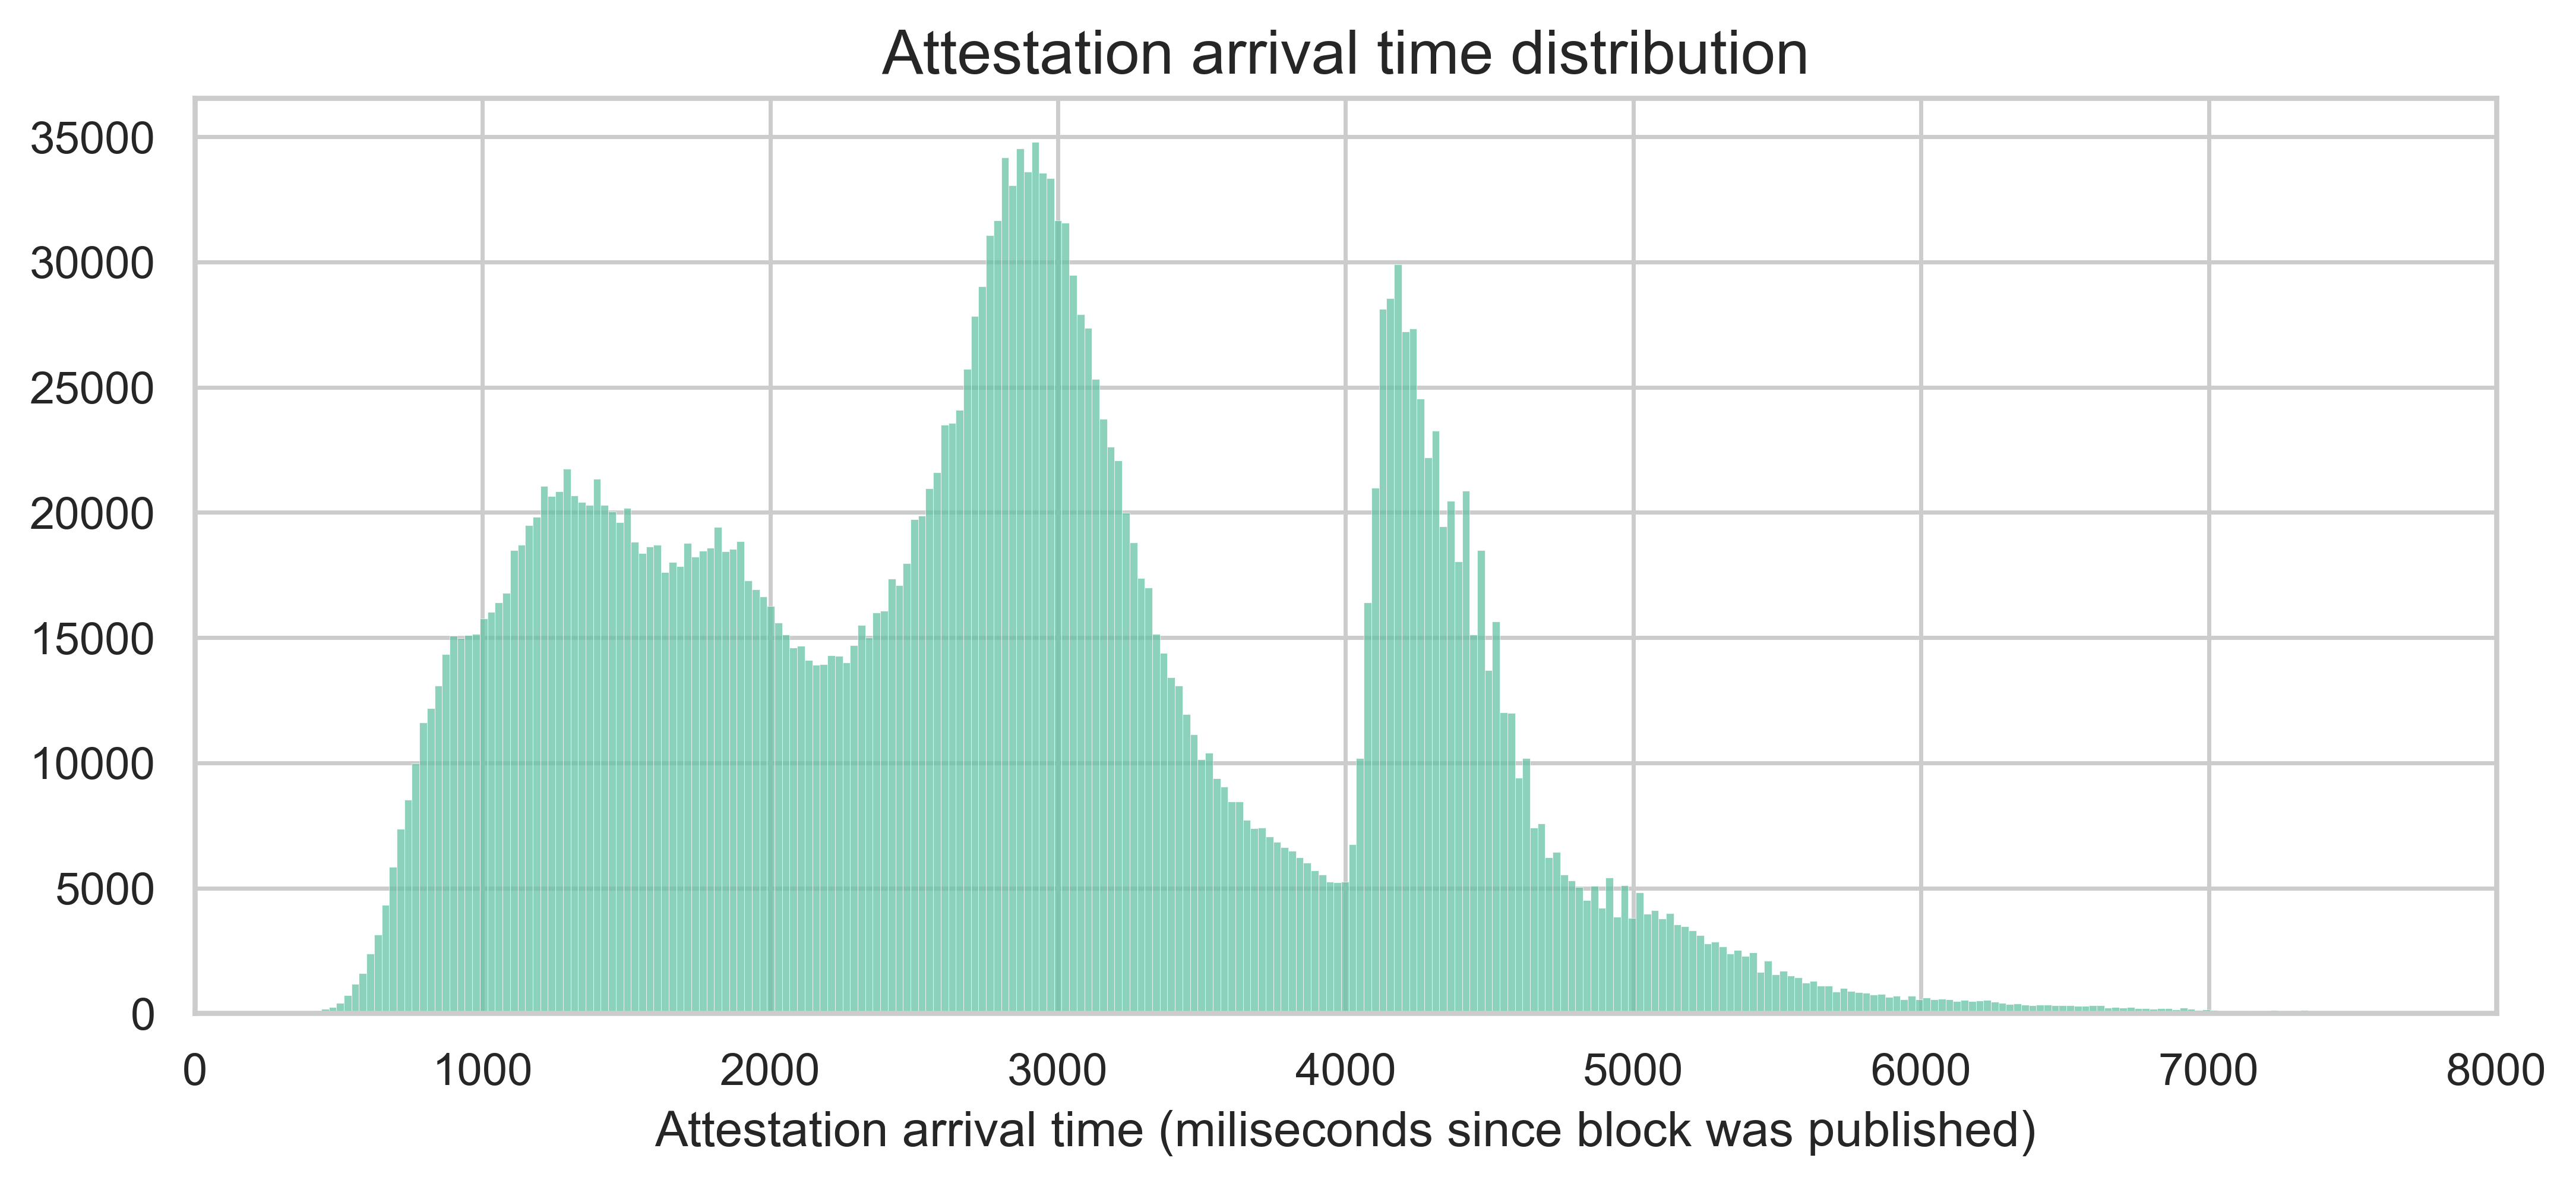

In [11]:
plt.figure(figsize=(10, 4))
sns.histplot(
    data=df,
    x="net_atts_arrival_time_ms"
)
plt.xlim(0,8000)
plt.title("Attestation arrival time distribution")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [12]:
sum(df["net_atts_arrival_time_ms"]>4500), sum(df["net_atts_arrival_time_ms"]>4500)/len(df)

(231311, 0.08094094181662308)

### Arrival times by block source

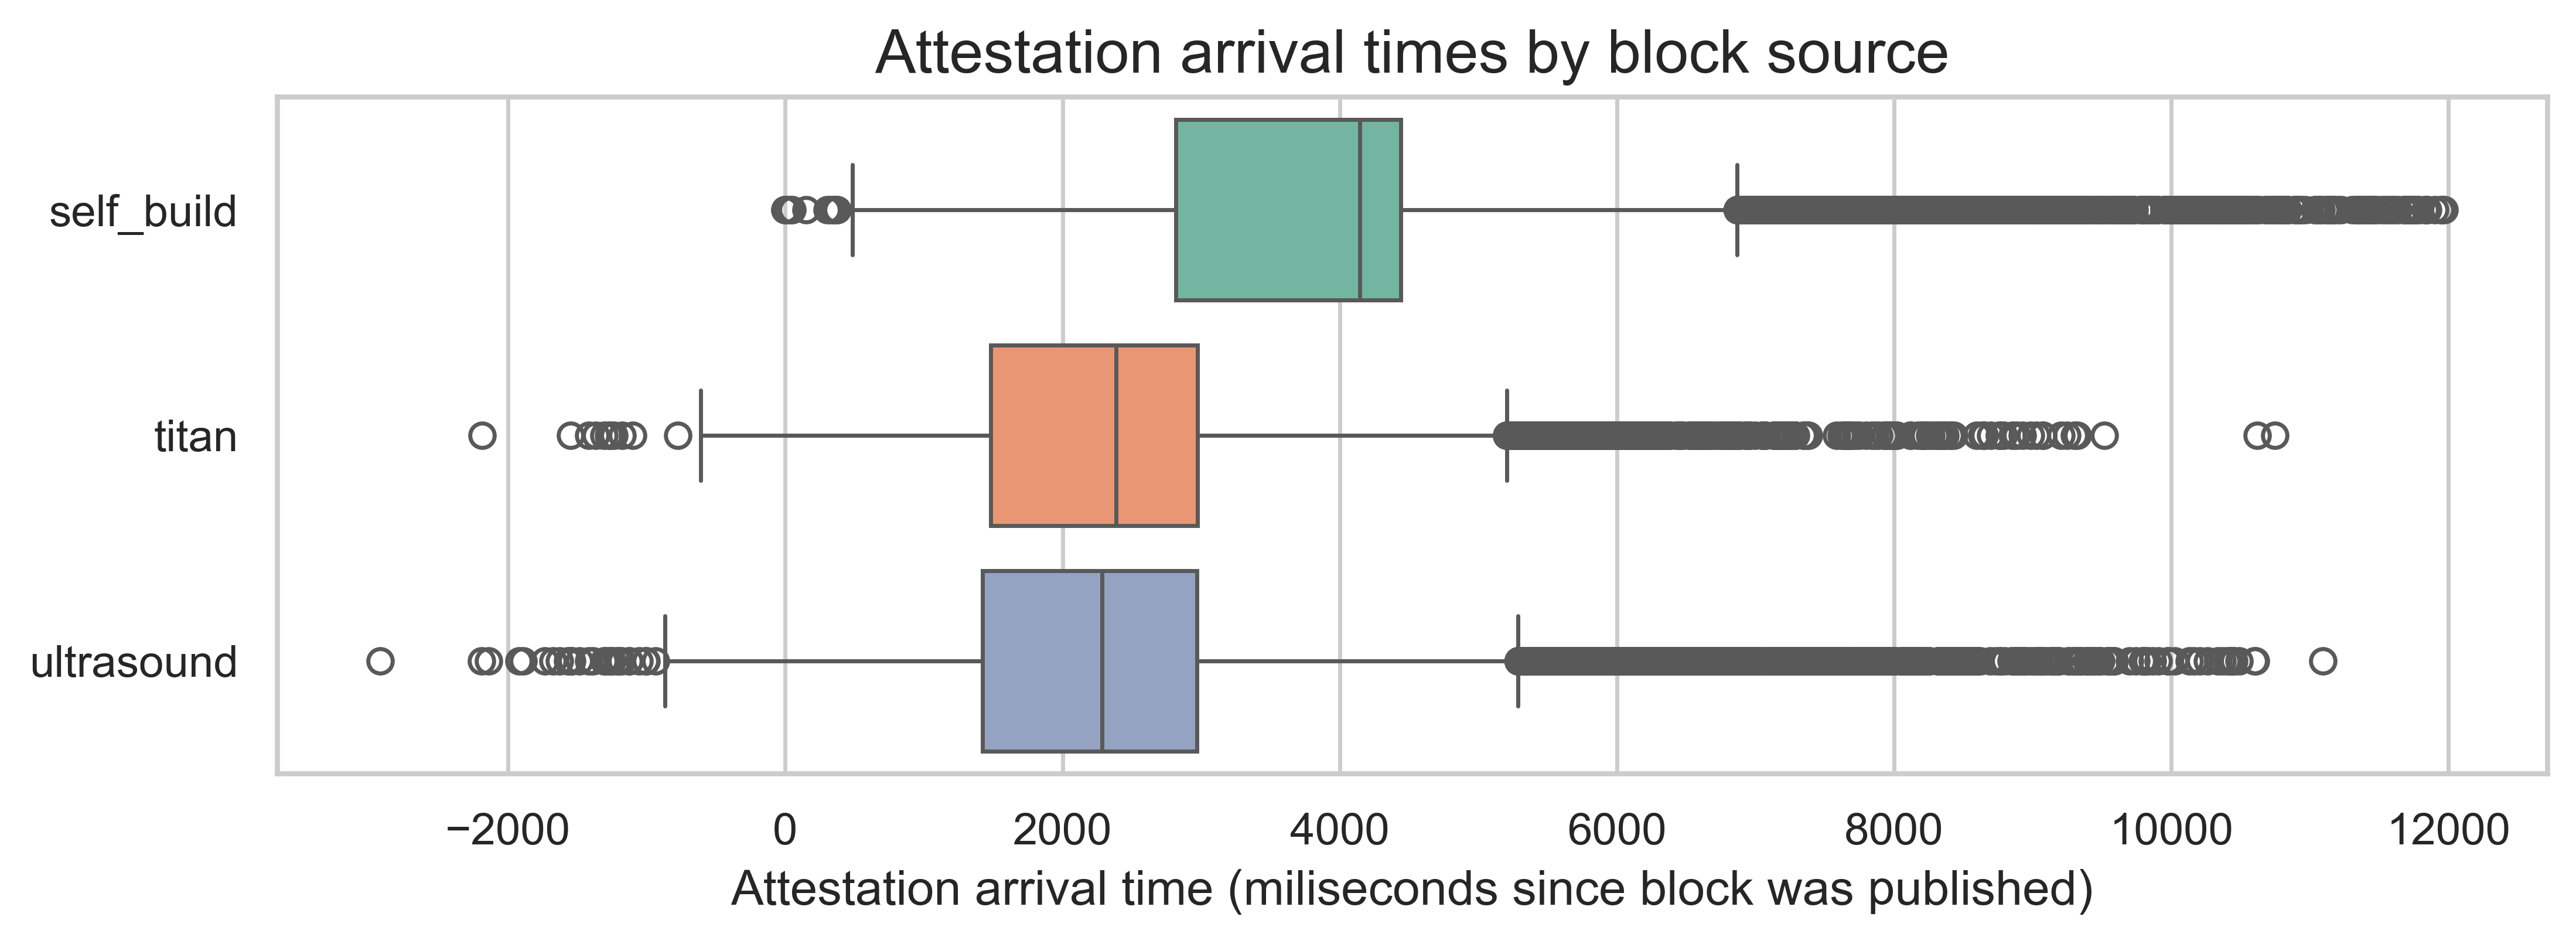

In [13]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="net_atts_arrival_time_ms",
    y="header_from",
    hue="header_from",
    legend=False
)
plt.title("Attestation arrival times by block source")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [14]:
df[df["net_atts_arrival_time_ms"] < 0]["header_from"].value_counts()

header_from
ultrasound    100
titan          16
Name: count, dtype: int64

In [15]:
df.columns

Index(['slot', 'atts_validator', 'atts_subnet', 'atts_arrival_time_ms',
       'request_datetime', 'publish_datetime', 'header_from',
       'slot_start_datetime', 'request_time_ms', 'publish_time_ms',
       'p95_block_arrival_ms', 'p66_block_arrival_ms', 'avg_block_arrival_ms',
       'block_total_bytes_compressed', 'block_proposer_index',
       'block_gas_used', 'block_tx_count', 'entity',
       'net_atts_arrival_time_ms'],
      dtype='object')

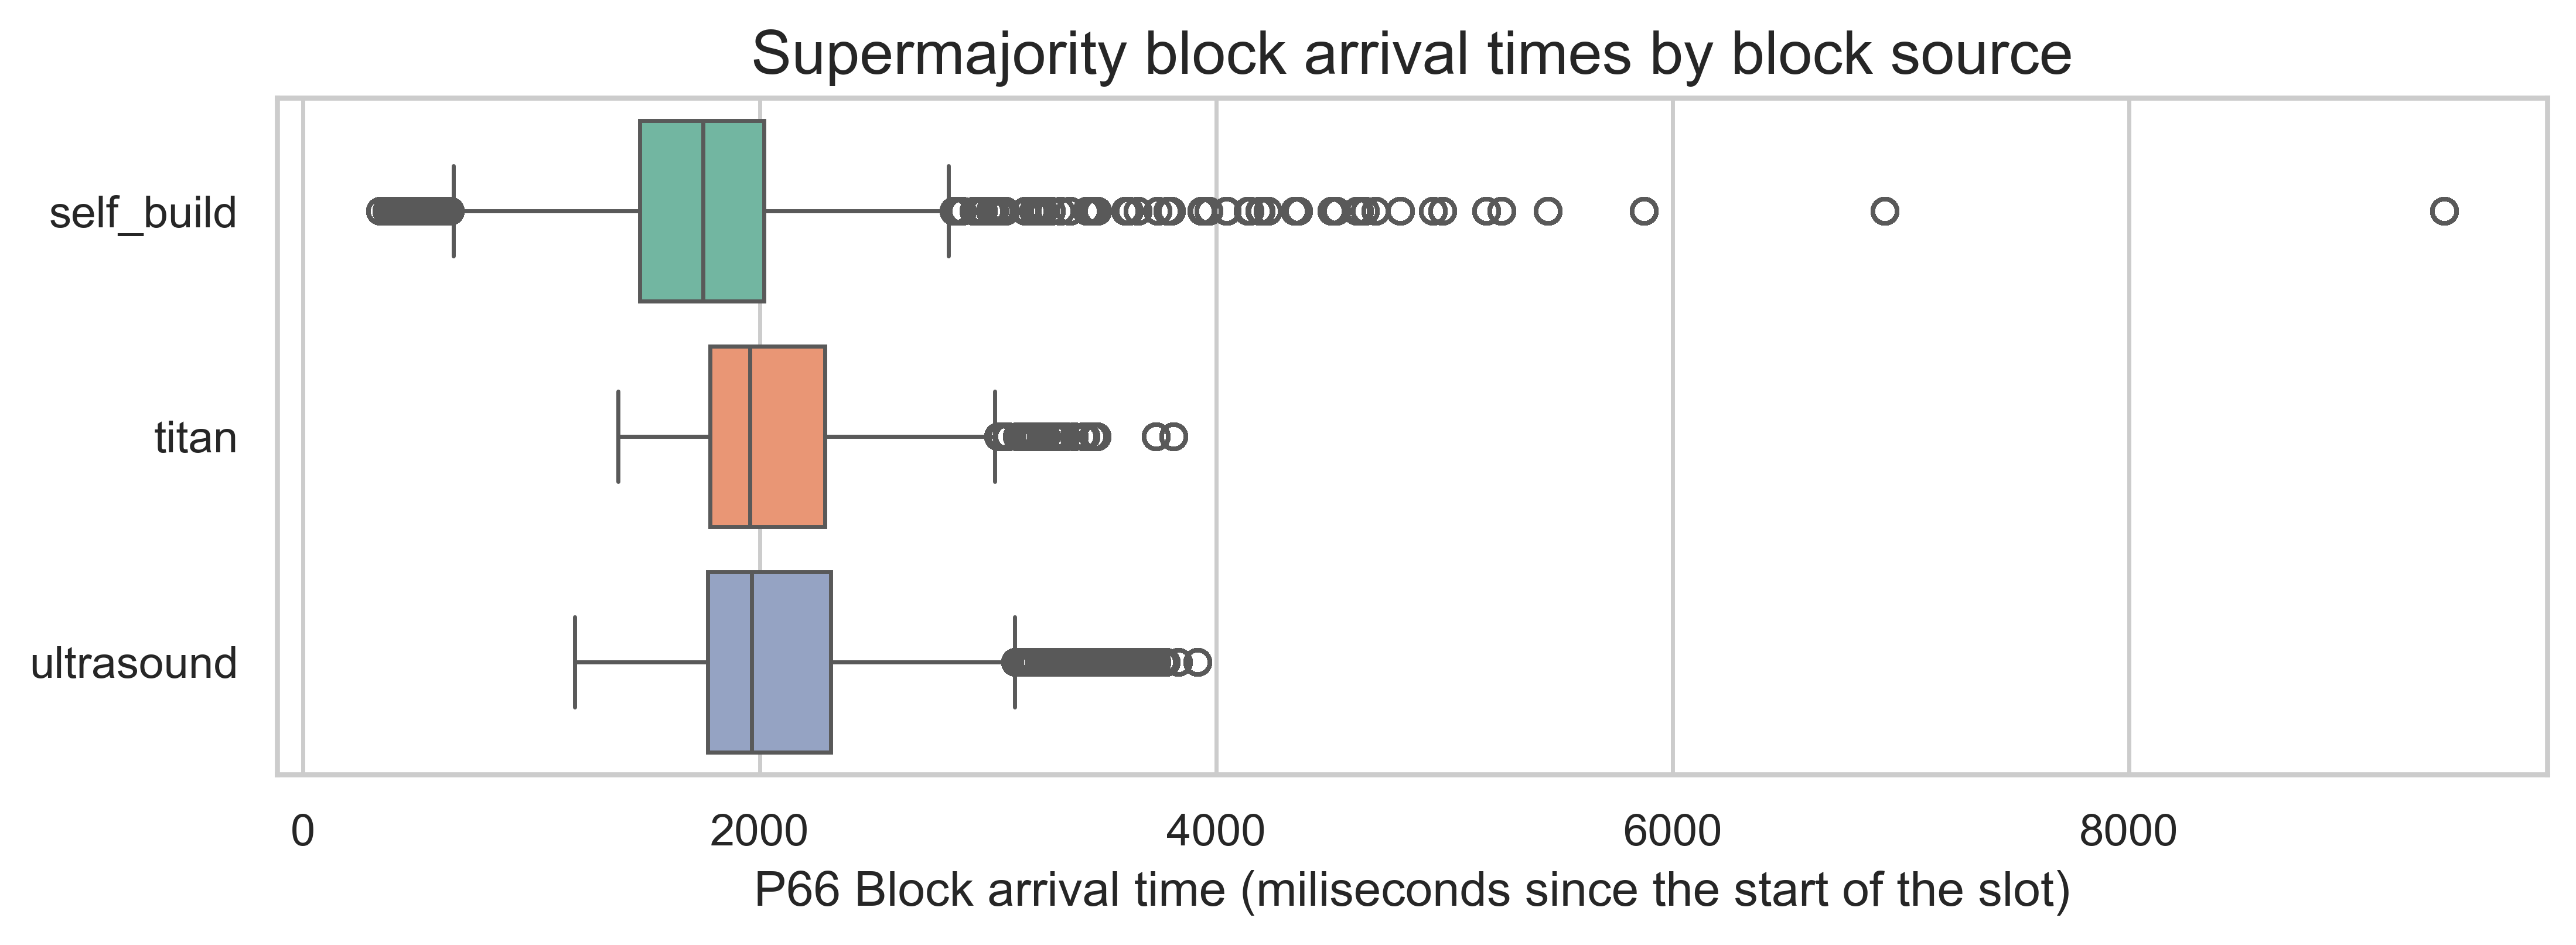

In [16]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="p66_block_arrival_ms",
    y="header_from",
    hue="header_from",
    legend=False
)
plt.title("Supermajority block arrival times by block source")
plt.ylabel("")
plt.xlabel("P66 Block arrival time (miliseconds since the start of the slot)")
plt.show()

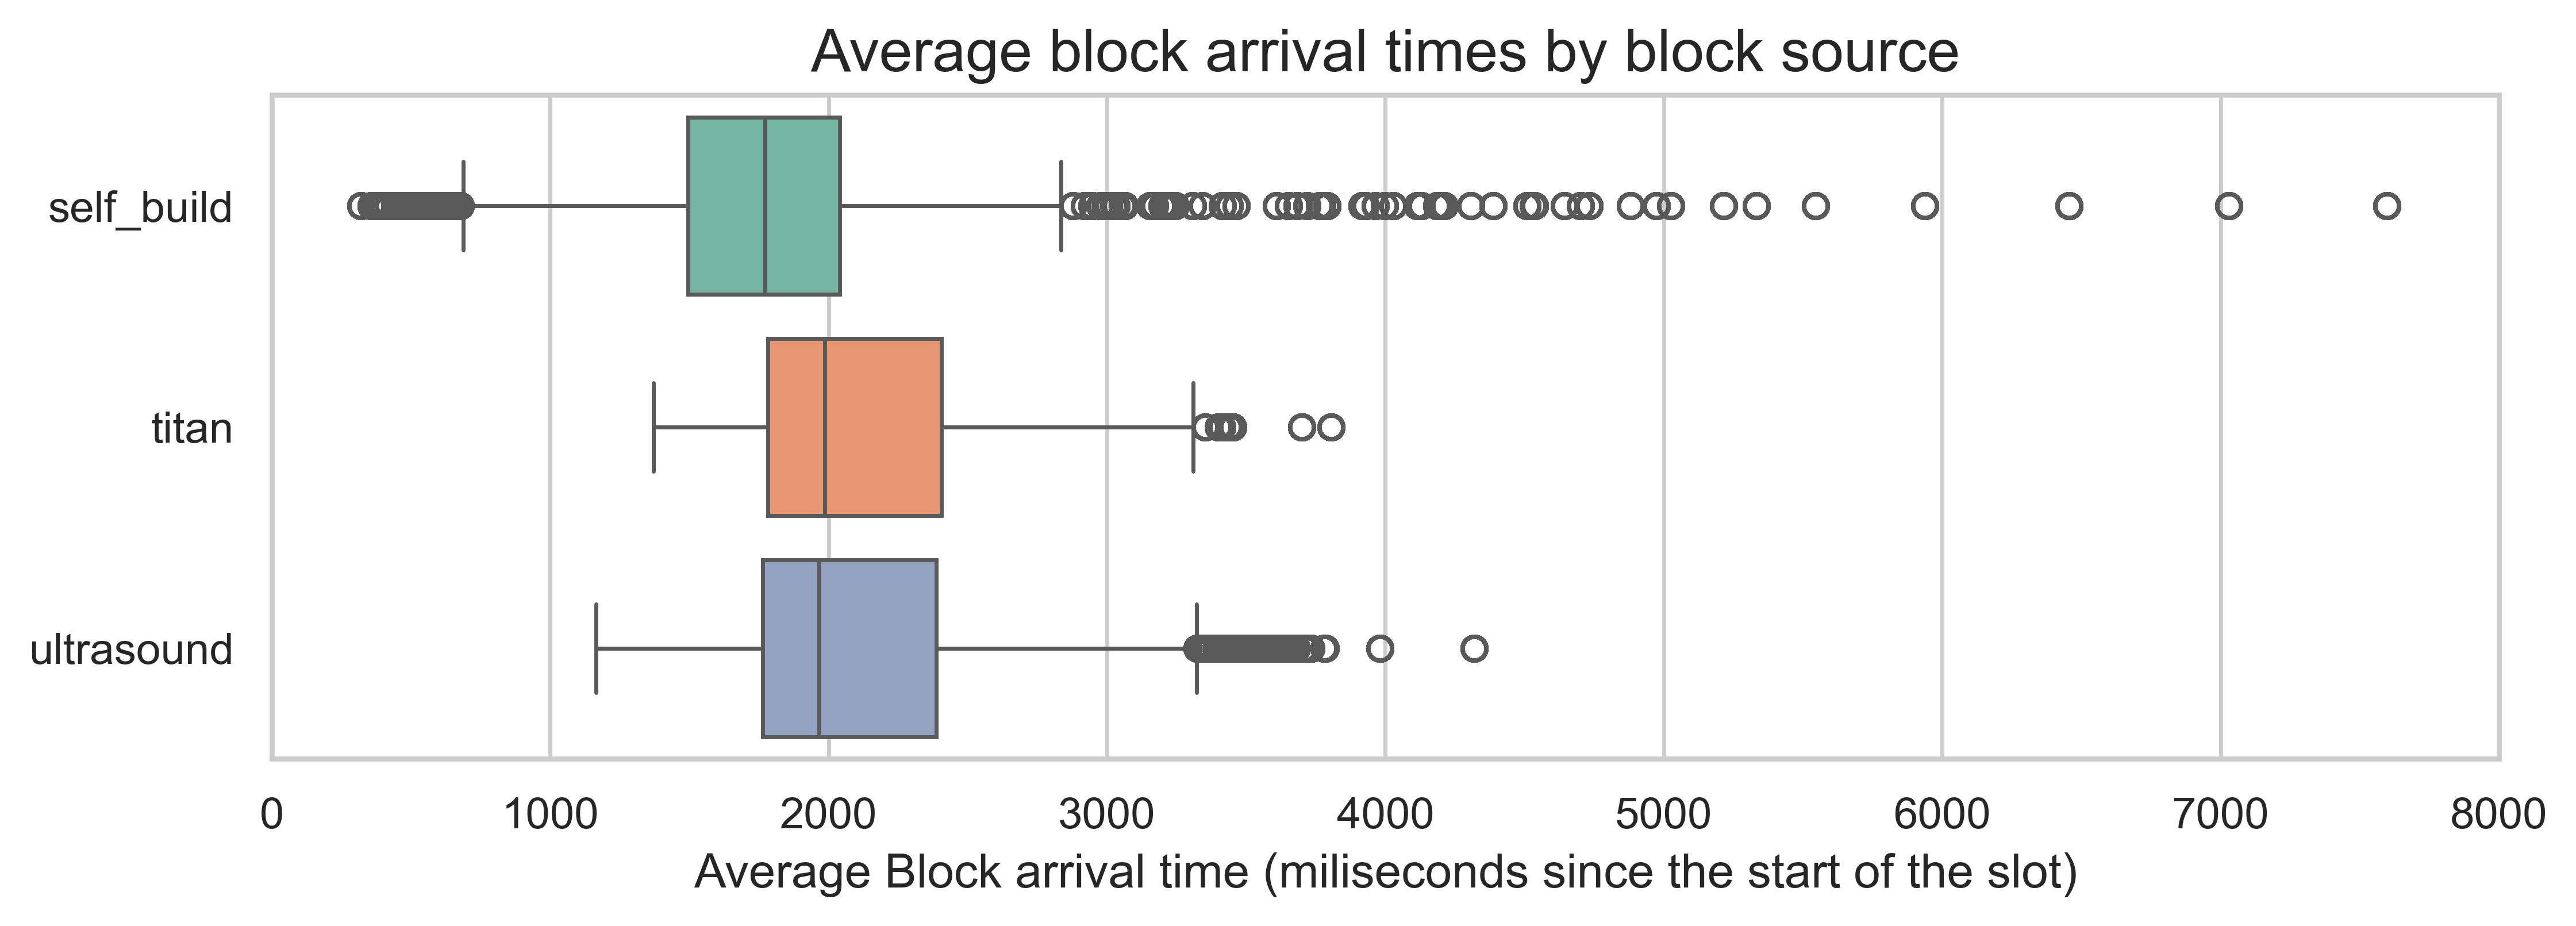

In [17]:
plt.figure(figsize=(10, 3))
sns.boxplot(
    data=df.sort_values("header_from"),
    x="avg_block_arrival_ms",
    y="header_from",
    hue="header_from",
    legend=False
)
plt.xlim(0,8000)
plt.title("Average block arrival times by block source")
plt.ylabel("")
plt.xlabel("Average Block arrival time (miliseconds since the start of the slot)")
plt.show()

### Arrival times by entity

In [18]:
entity_counts = df["entity"].value_counts()/len(df)
ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
ent_df["entity"] = np.where(ent_df["count"]>0.01, ent_df["entity"], "other")
ent_df = ent_df.sort_values("count", ascending=False)

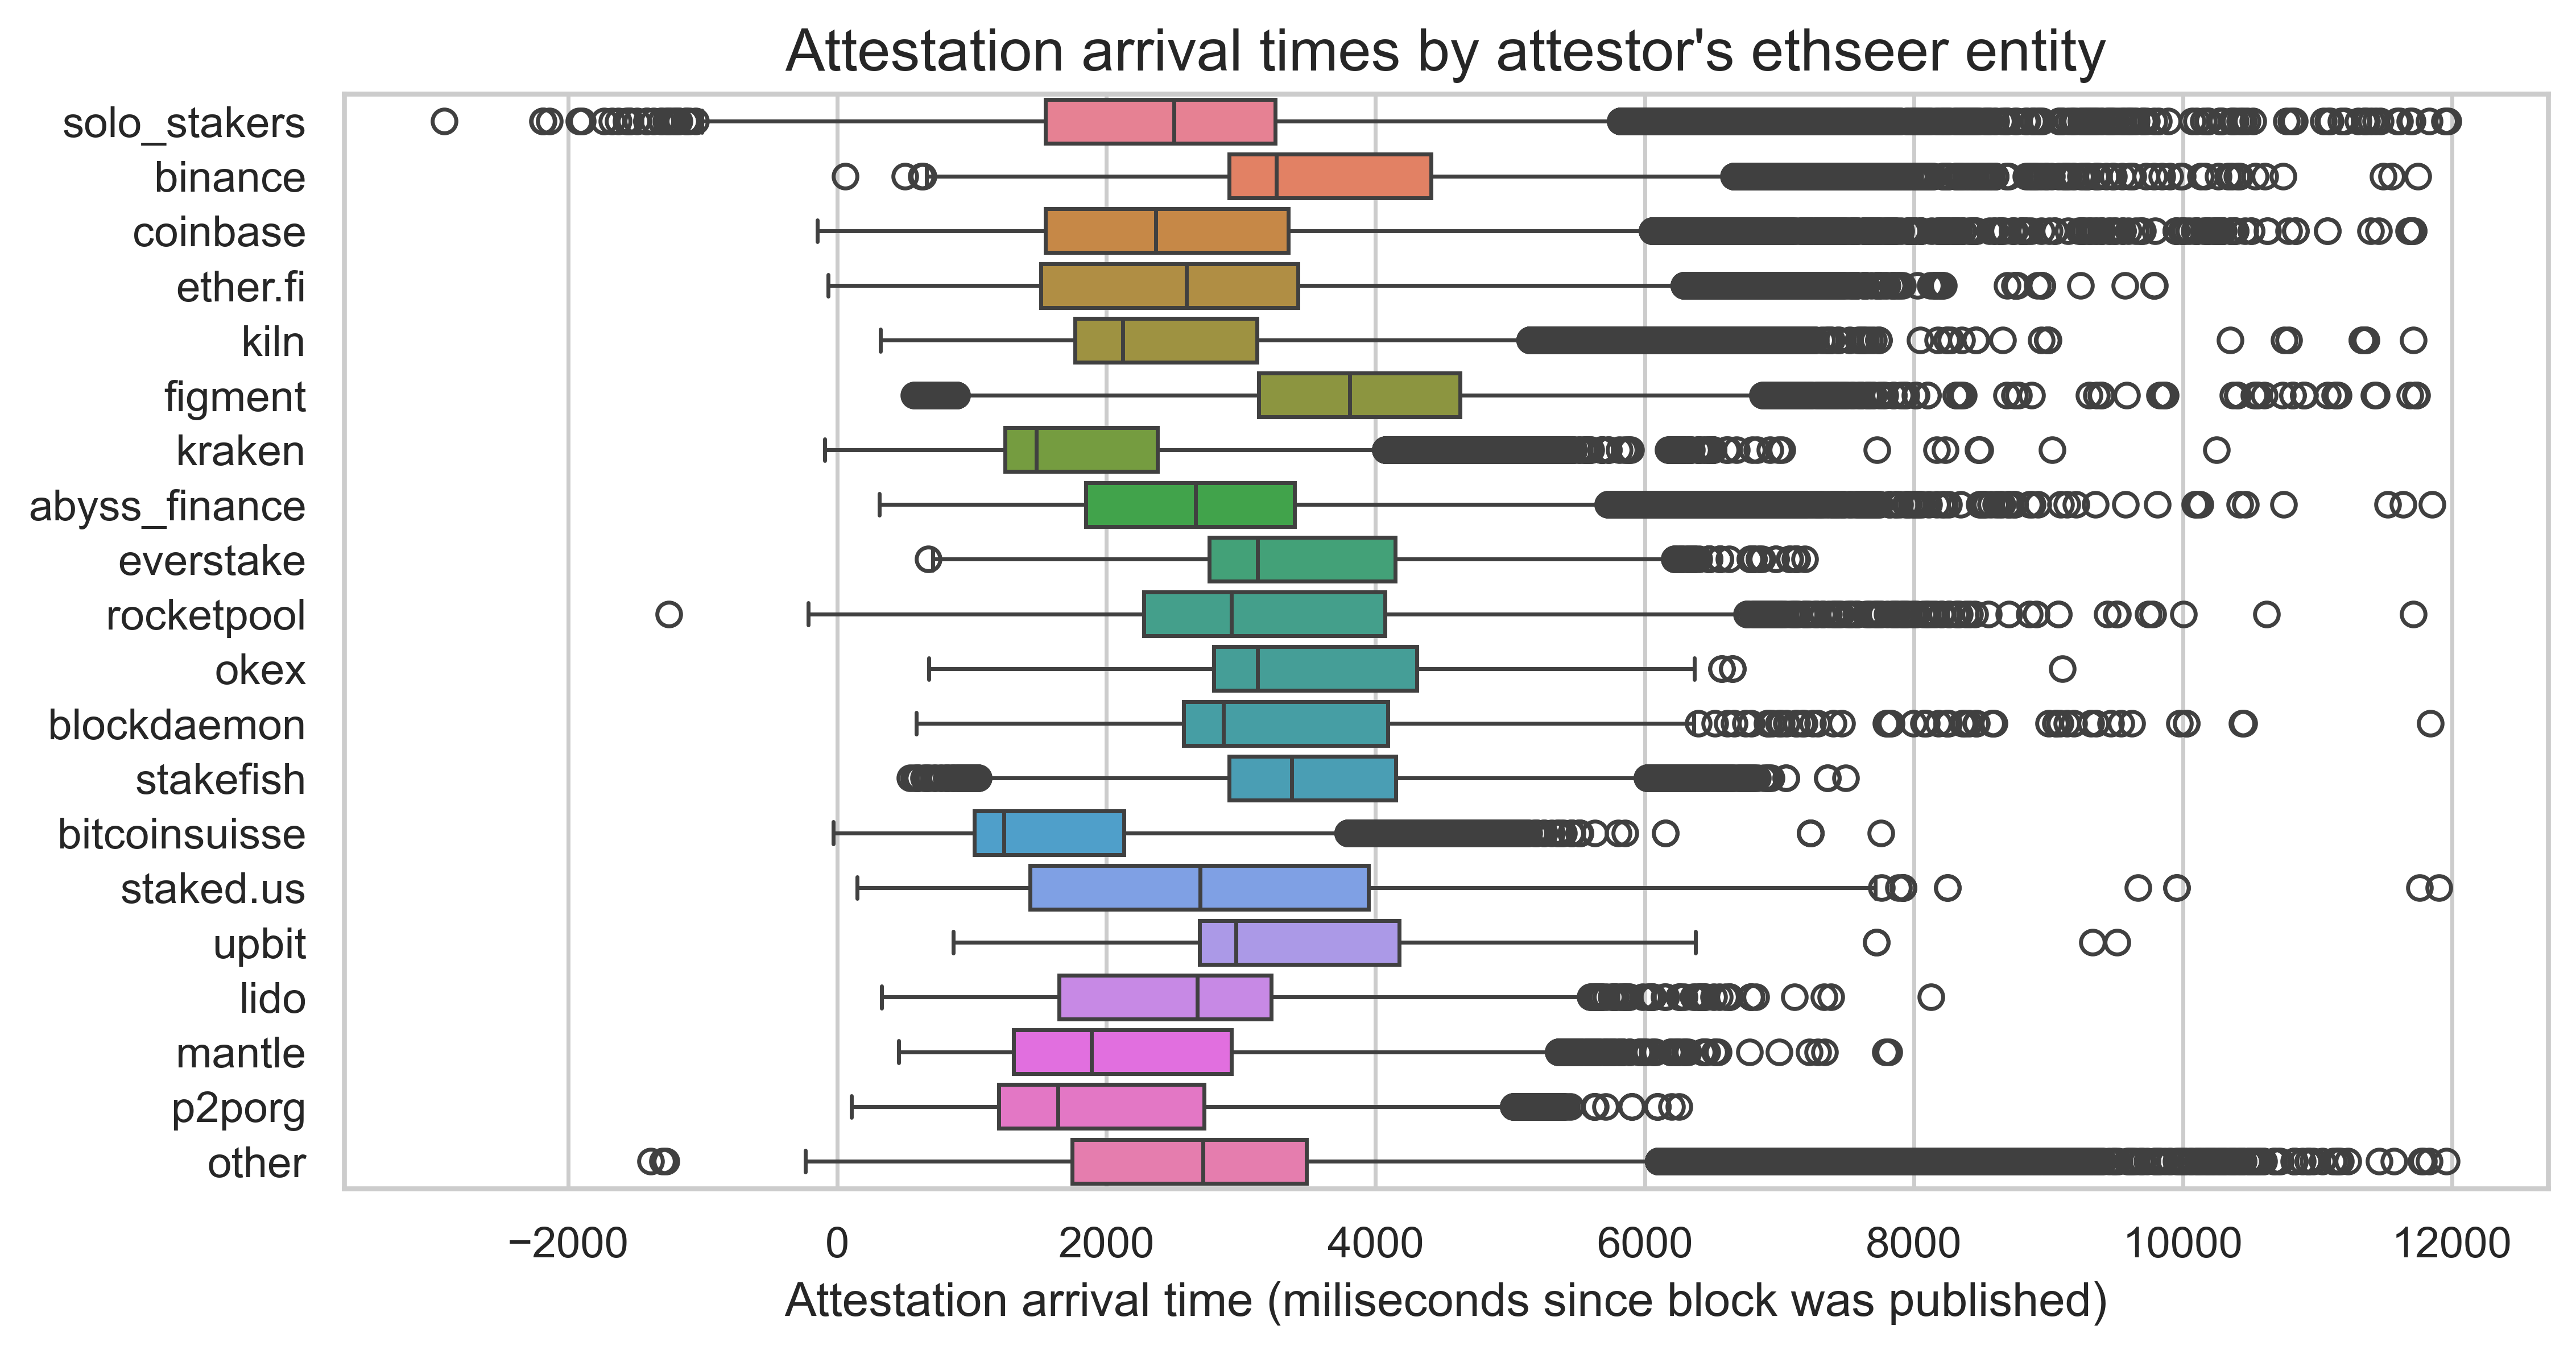

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=ent_df,
    x="net_atts_arrival_time_ms",
    y="entity",
    hue="entity",
    legend=False
)
plt.title("Attestation arrival times by attestor's ethseer entity")
plt.ylabel("")
plt.xlabel("Attestation arrival time (miliseconds since block was published)")
plt.show()

In [20]:
(ent_df.groupby("entity").size().sort_values(ascending=False)/len(ent_df)).head(20)

entity
other            0.394736
solo_stakers     0.084927
binance          0.084512
coinbase         0.070639
ether.fi         0.068646
kiln             0.043344
figment          0.036388
kraken           0.036287
abyss_finance    0.019240
everstake        0.018756
rocketpool       0.018370
okex             0.018248
blockdaemon      0.017669
stakefish        0.016545
bitcoinsuisse    0.013554
staked.us        0.013211
upbit            0.013100
lido             0.011203
mantle           0.010457
p2porg           0.010167
dtype: float64

In [21]:
ent_df[ent_df["net_atts_arrival_time_ms"] < 0]["entity"].value_counts().head(10)

entity
solo_stakers     78
other            18
coinbase         12
ether.fi          4
rocketpool        2
kraken            1
bitcoinsuisse     1
Name: count, dtype: int64

### Late arrivals (i.e. >4.5s)

In [22]:
late_df = df.copy()
late_df["is_late"] = late_df["net_atts_arrival_time_ms"] > 4500

sum(late_df["is_late"])/len(late_df)

0.08094094181662308

In [23]:
entity_counts = df["entity"].value_counts()/len(df)
ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
ent_df["entity"] = np.where(ent_df["count"]>0.01, ent_df["entity"], "other")

temp_df = ent_df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "entity"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index="entity", values=0)
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["atts_rate"] = (temp_df[True] + temp_df[False])/len(df)
temp_df.sort_values("late_rate", ascending=False)

is_late,False,True,late_rate,atts_rate
entity,,,,
figment,74162,29827,0.286828,0.036388
stakefish,38028,9255,0.195736,0.016545
binance,198430,43085,0.178395,0.084512
staked.us,32131,5623,0.148938,0.013211
everstake,48131,5469,0.102034,0.018756
ether.fi,179033,17141,0.087377,0.068646
coinbase,184433,17437,0.086377,0.070639
rocketpool,48245,4253,0.081013,0.018370
okex,48616,3533,0.067748,0.018248


In [24]:
entity_counts = df["entity"].value_counts()/len(df)
temp_ent_df = df.merge(entity_counts, left_on="entity", right_index=True)
temp_ent_df["entity"] = np.where(temp_ent_df["count"]>0.001, temp_ent_df["entity"], "other")

temp_df = temp_ent_df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "entity"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index="entity", values=0)
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["atts_rate"] = (temp_df[True] + temp_df[False])/len(df)
temp_df[temp_df["late_rate"]>temp_df["atts_rate"]].sort_values("late_rate", ascending=False)

is_late,False,True,late_rate,atts_rate
entity,,,,
coinspot,6583,4771,0.420204,0.003973
figment_lido,12208,6820,0.358419,0.006658
figment,74162,29827,0.286828,0.036388
whale_0x8914,3657,1268,0.257462,0.001723
piertwo,3708,1233,0.249545,0.001729
...,...,...,...,...
revolut,5085,33,0.006448,0.001791
xhash,3353,17,0.005045,0.001179
hashhub,3650,15,0.004093,0.001282


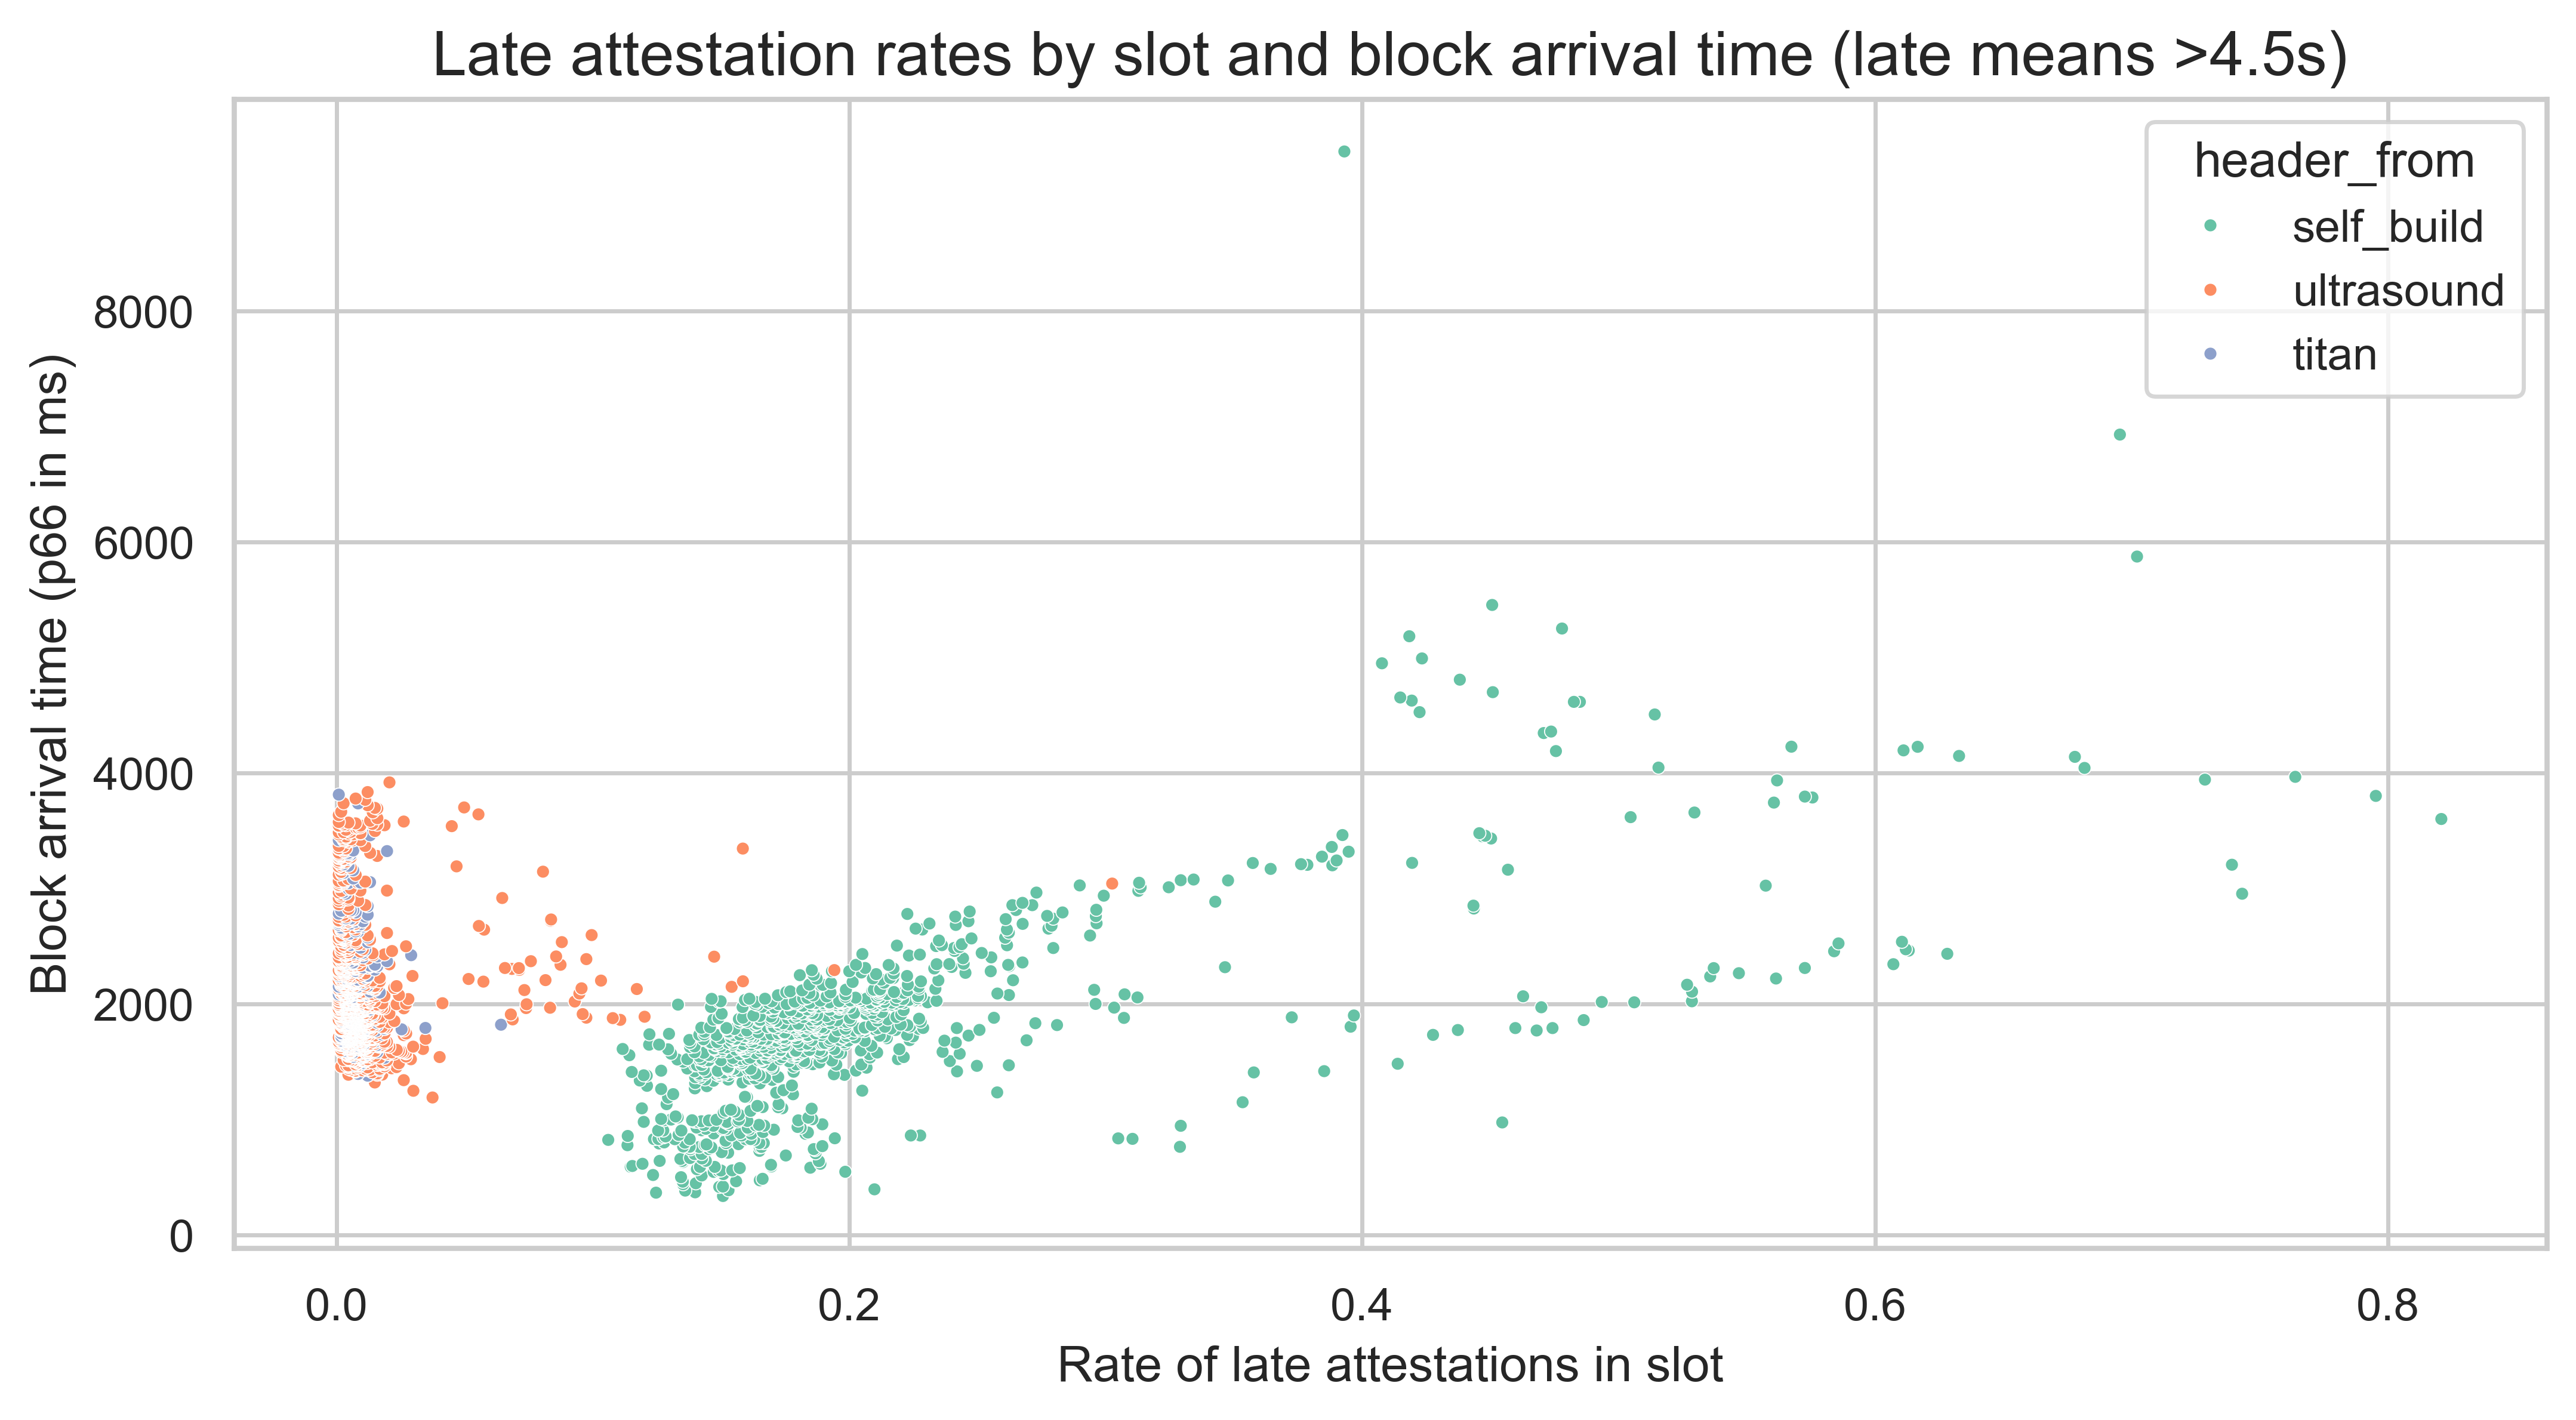

In [25]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","p66_block_arrival_ms", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","p66_block_arrival_ms", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])


plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("p66_block_arrival_ms"),
    x="late_rate",
    y="p66_block_arrival_ms",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and block arrival time (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Block arrival time (p66 in ms)")

plt.show()

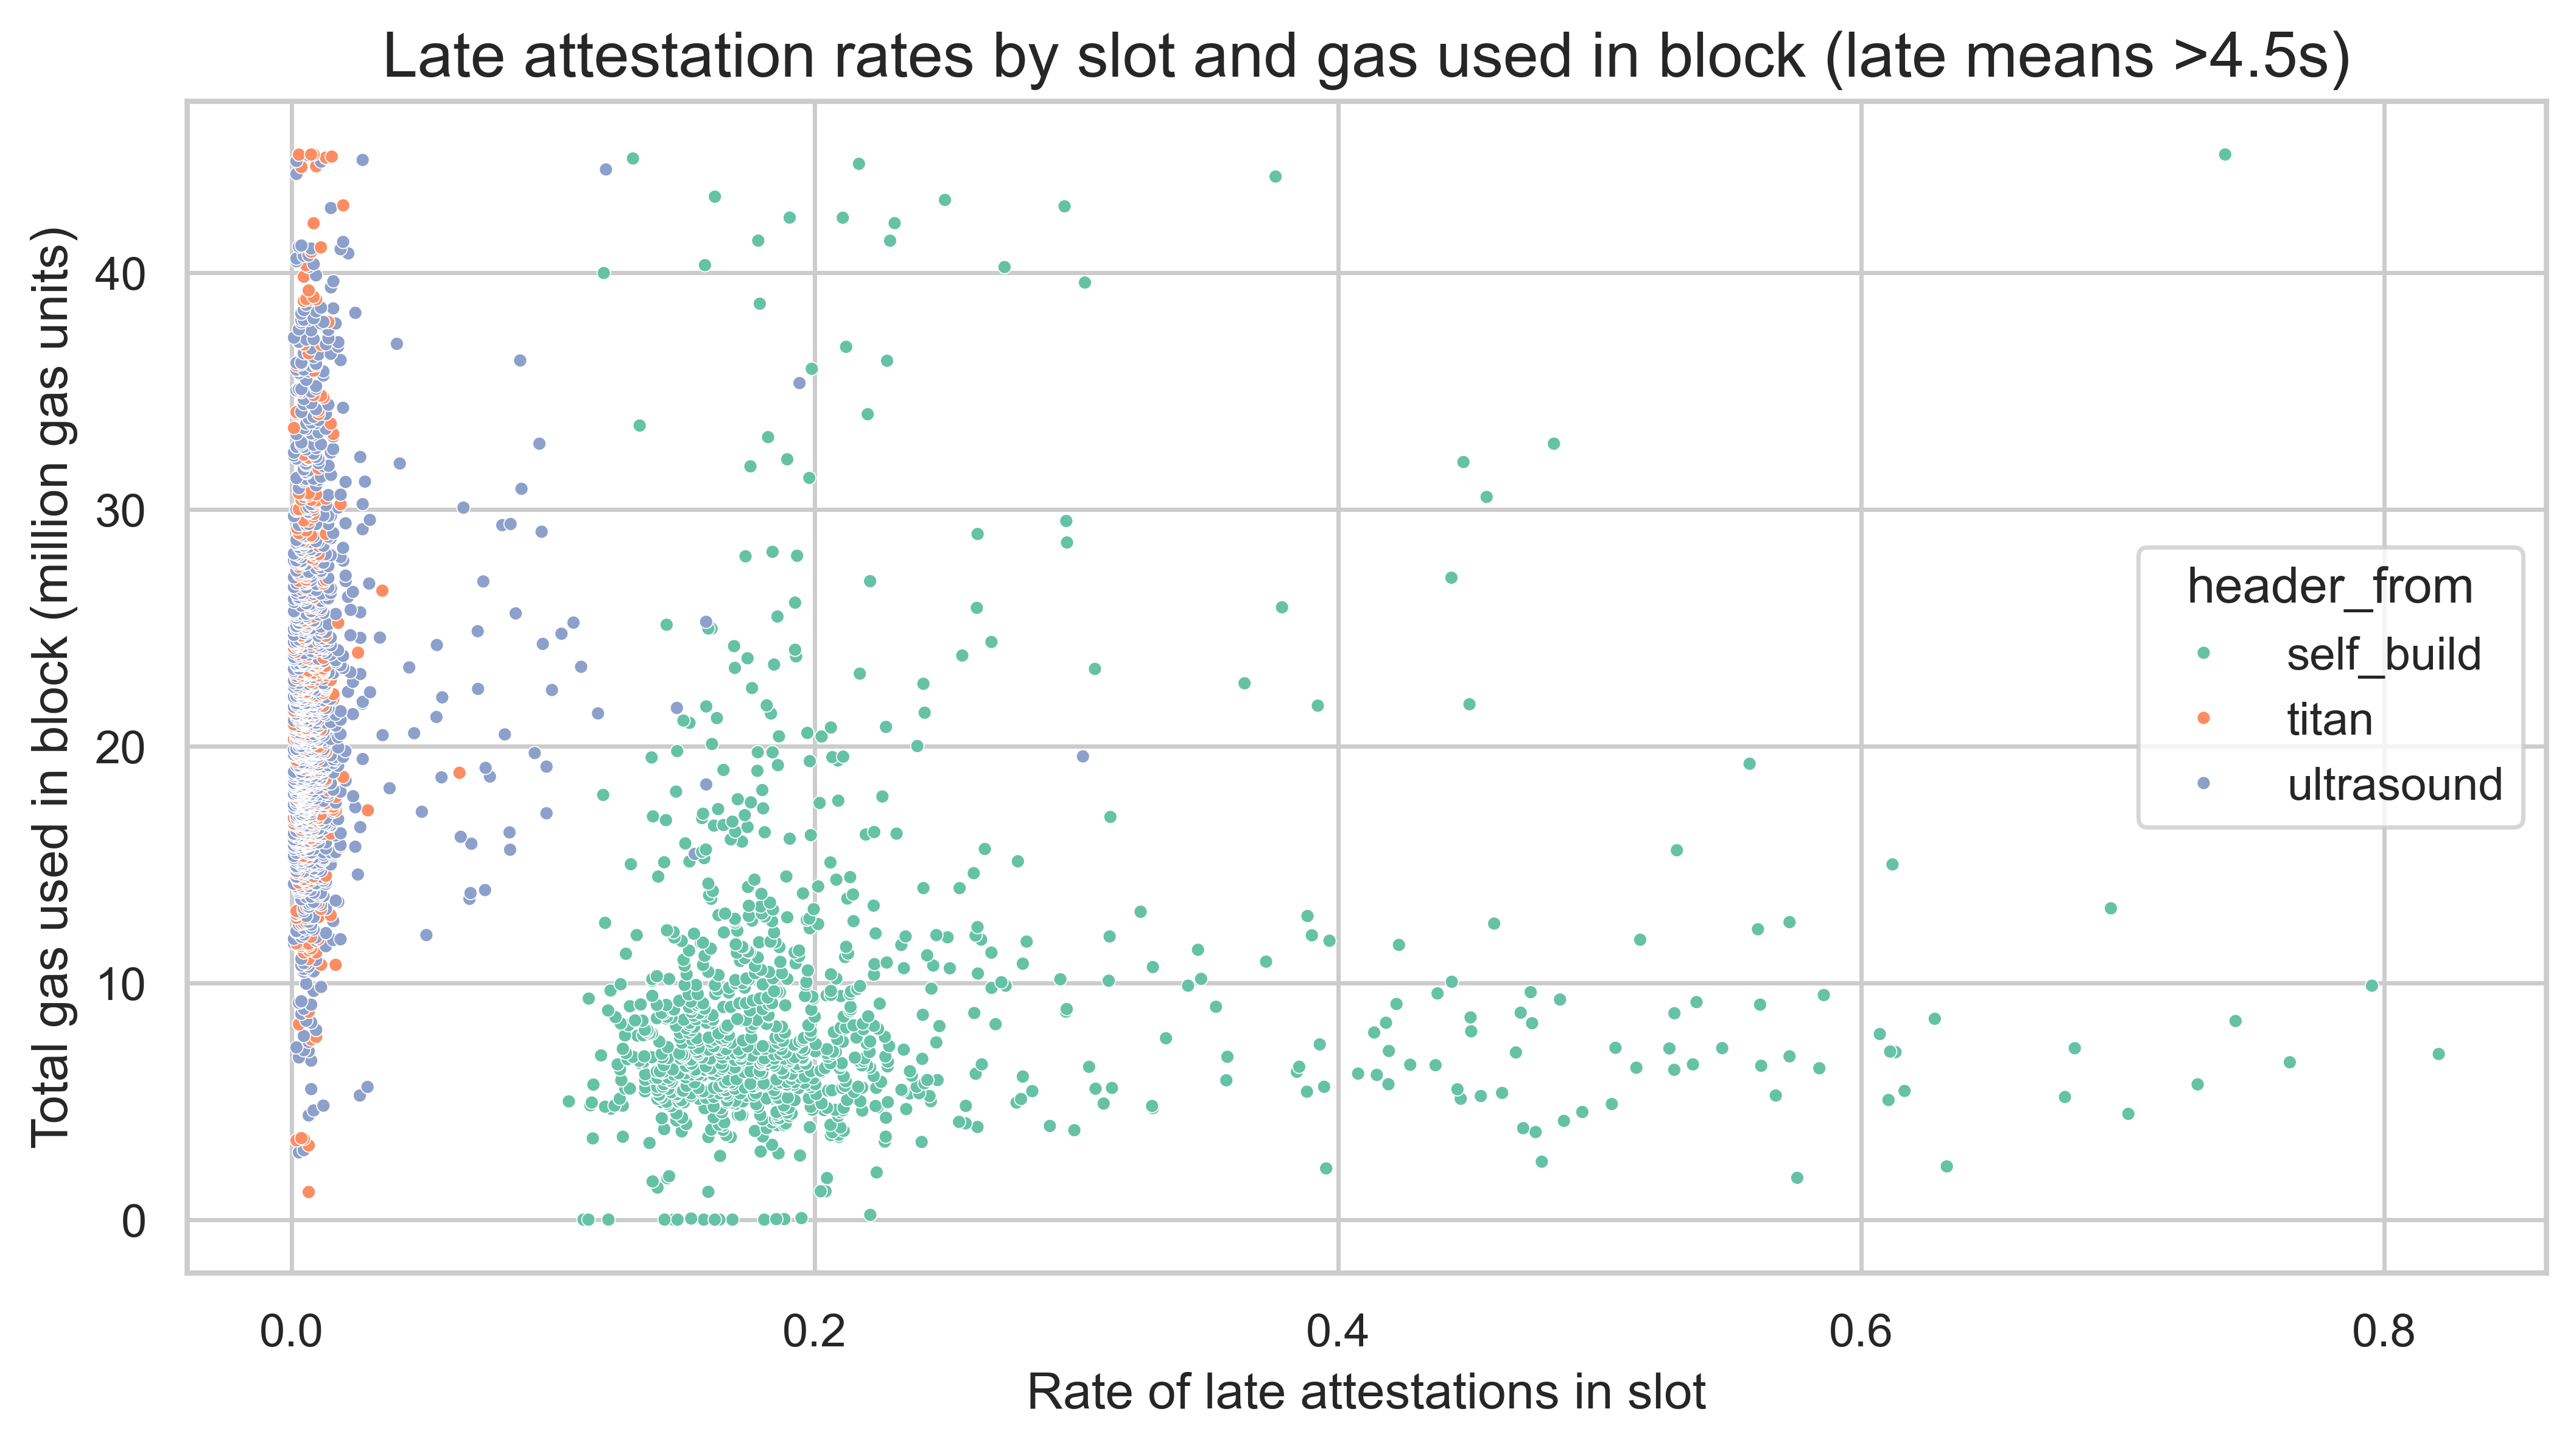

In [26]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot", "block_gas_used", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_gas_used", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])
temp_df["block_gas_used"] = temp_df["block_gas_used"]/1000000


plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("block_gas_used"),
    x="late_rate",
    y="block_gas_used",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and gas used in block (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Total gas used in block (million gas units)")

plt.show()

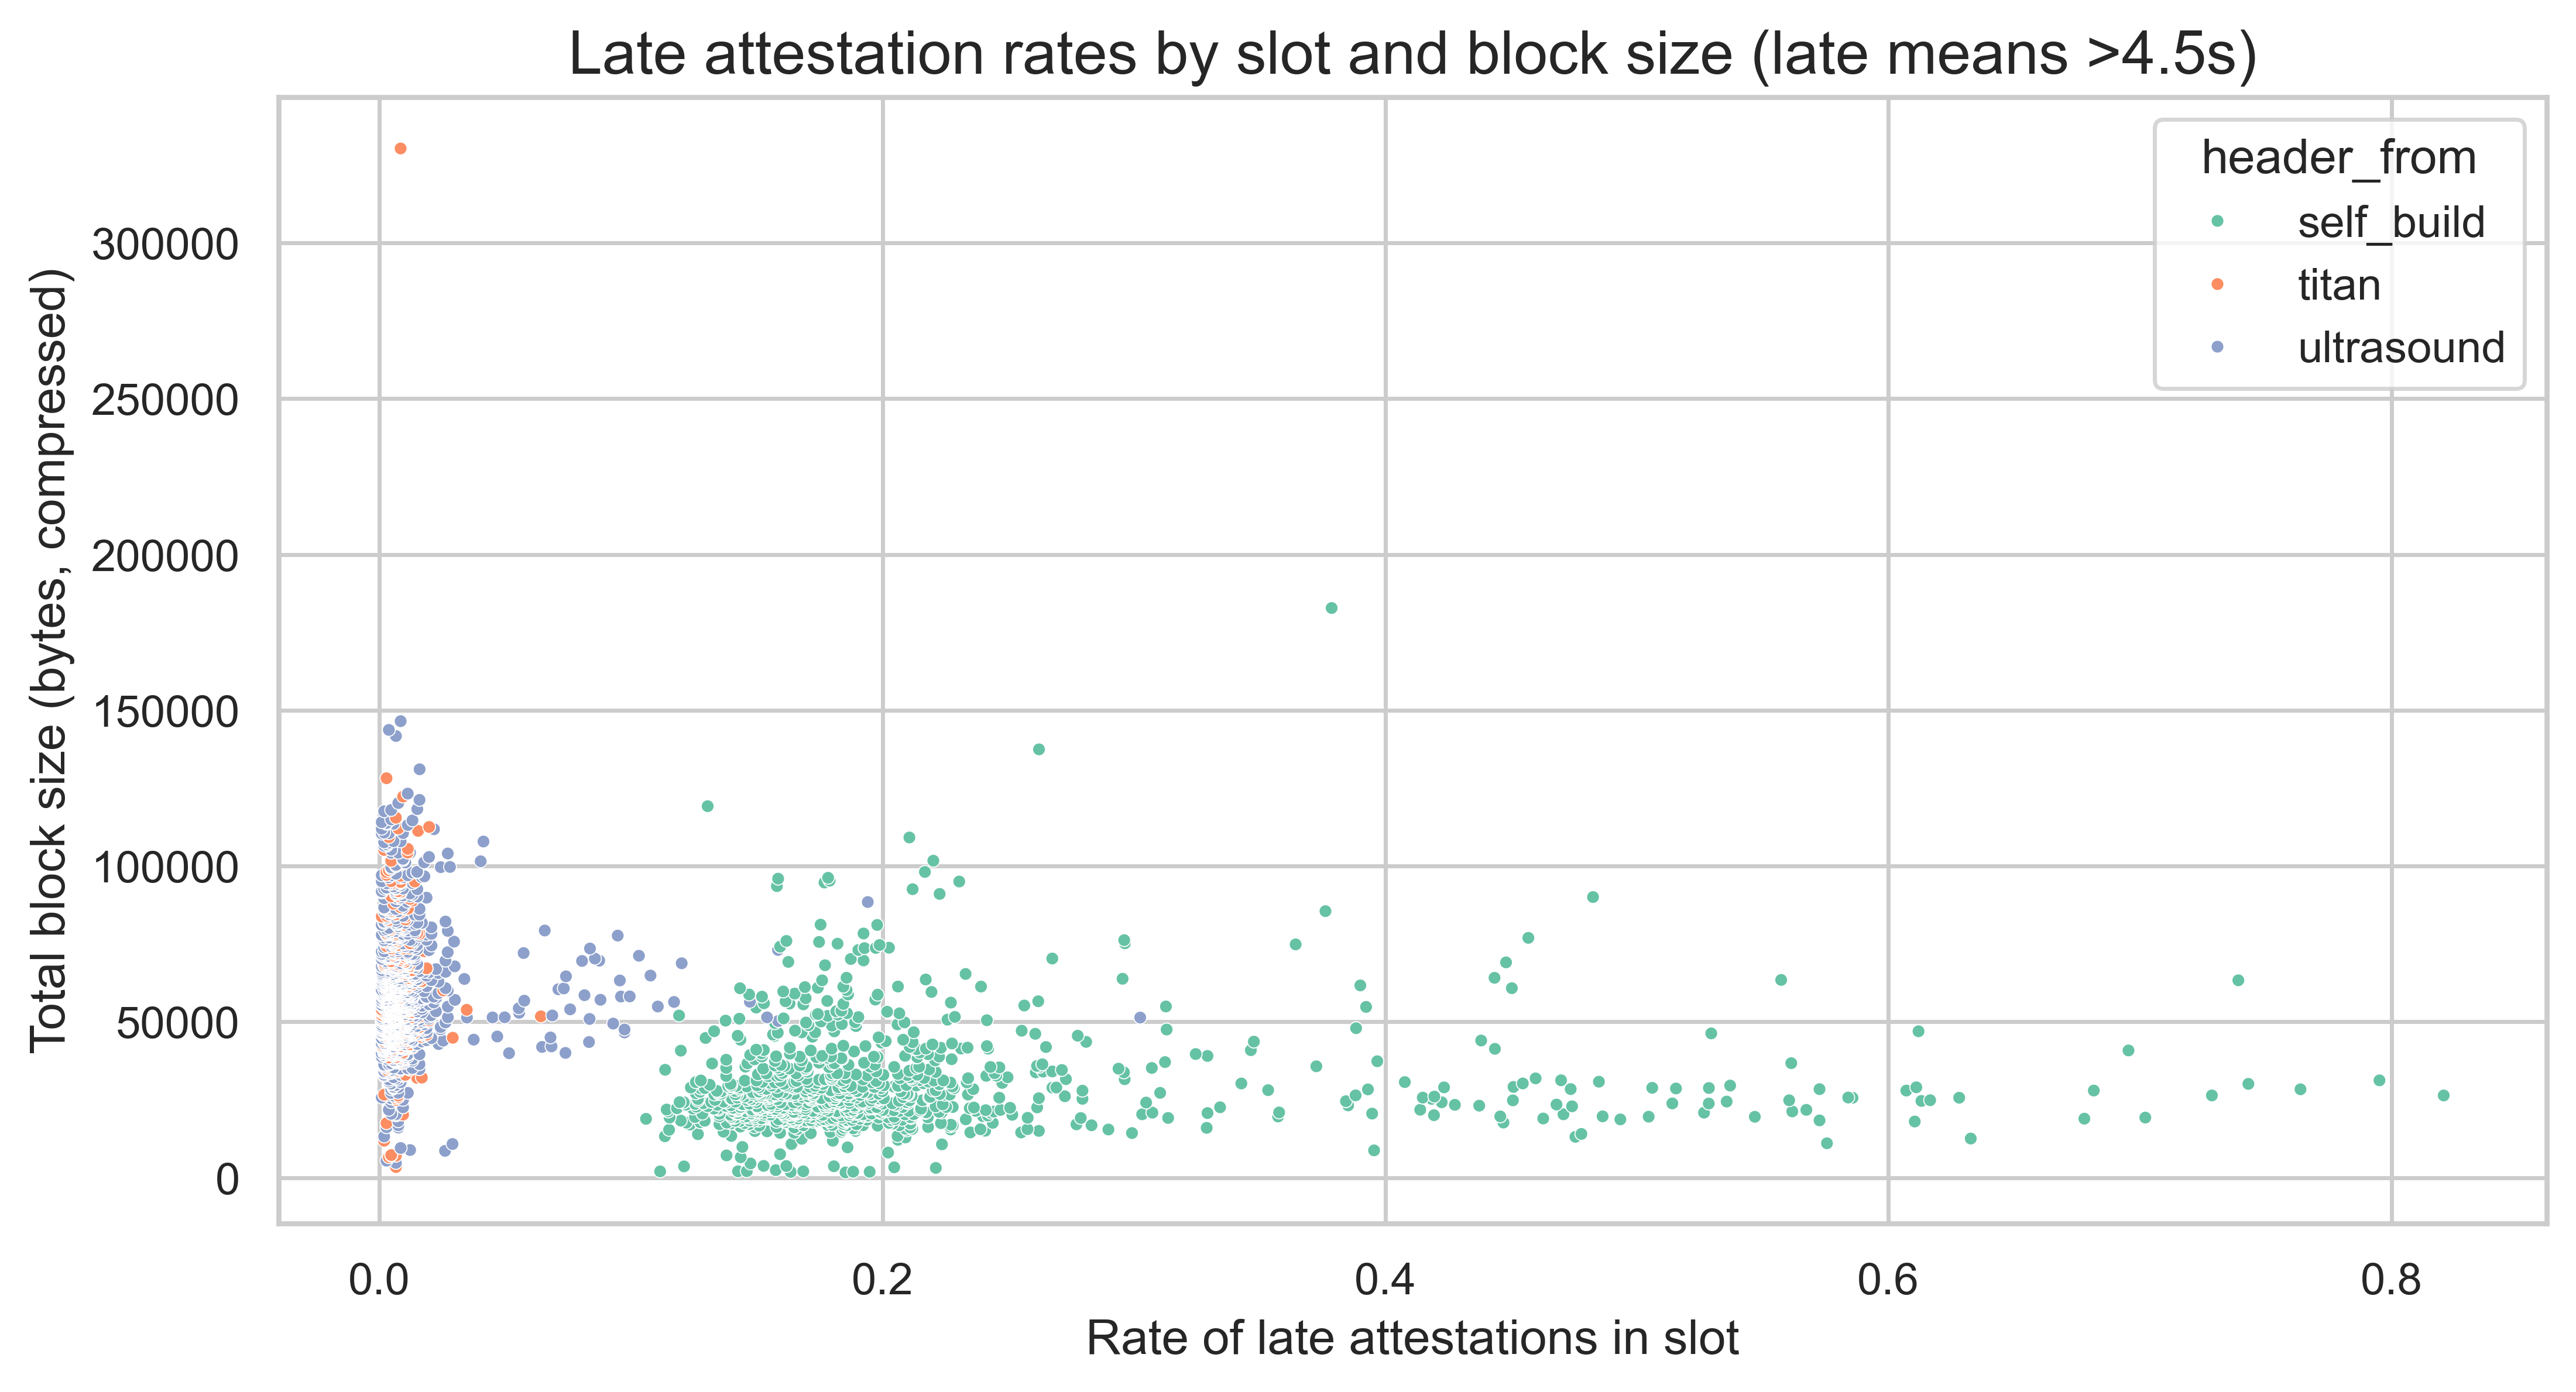

In [27]:
temp_df = df.copy()
temp_df["is_late"] = temp_df["net_atts_arrival_time_ms"] > 4500
temp_df = (
    temp_df.groupby(["is_late", "slot","block_total_bytes_compressed", "header_from"])
    .size()
    .reset_index()
    .pivot(columns="is_late", index=["slot","block_total_bytes_compressed", "header_from"], values=0)
    .reset_index()
)
temp_df["late_rate"] = temp_df[True] / (temp_df[True] + temp_df[False])


plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=temp_df.sort_values("block_total_bytes_compressed"),
    x="late_rate",
    y="block_total_bytes_compressed",
    hue="header_from",
    s=10
)
plt.title("Late attestation rates by slot and block size (late means >4.5s)")
plt.xlabel("Rate of late attestations in slot")
plt.ylabel("Total block size (bytes, compressed)")

plt.show()